In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import mlflow

In [2]:

# from https://github.com/MaartenSchoukens/nonlinear_benchmarks/blob/master/submission_examples/silverbox.py

import nonlinear_benchmarks

# Load data: 
# Keep this part fixed, though you can split the train set further in a train and validation set. 
# Do not use the test set to make any decision about the model (parameters, hyperparameters, structure, ...)
train, test = nonlinear_benchmarks.Silverbox()
test_multisine, test_arrow_full, test_arrow_no_extrapolation = test
n = test_multisine.state_initialization_window_length



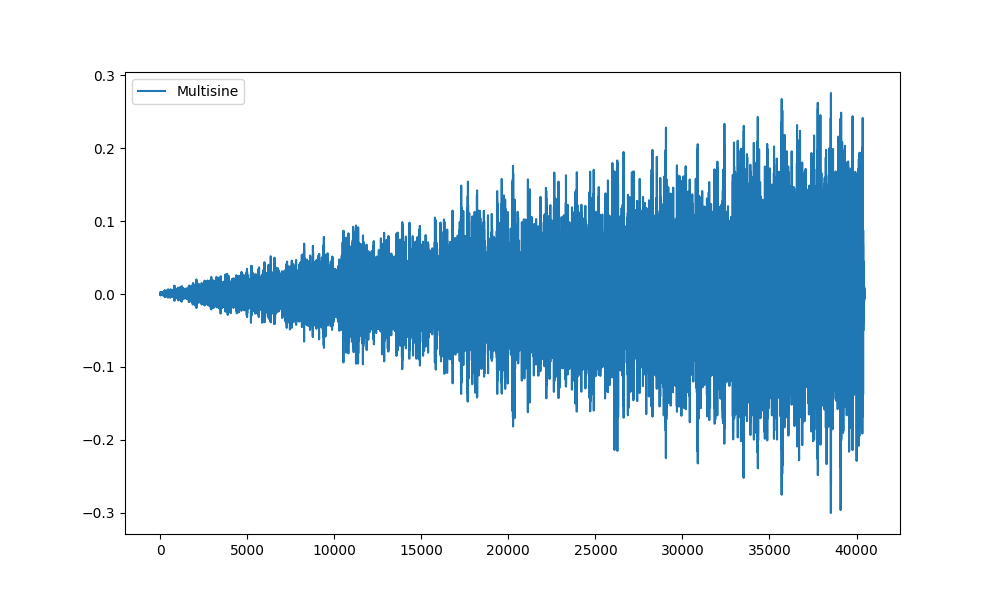

In [3]:
import matplotlib.pyplot as plt
%matplotlib widget

plt.figure(figsize=(10, 6))
plt.plot(test_arrow_full.y, label='Multisine')
plt.legend()
plt.show()

In [16]:
RUN_ID = '361516ead87d45e08fff01969a8e0f27'


In [17]:
# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from sysid.data import DataNormalizer
from sysid.models import SimpleLure

# Set MLflow tracking URI (adjust if needed)
mlflow_uri = project_root / "mlruns"
mlflow.set_tracking_uri(f"file://{mlflow_uri}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

# Load model architecture from MLflow (logged at end of training as 'final' model)
print(f"Loading model from run {RUN_ID}...")
model_uri = f"runs:/{RUN_ID}/model"
model = mlflow.pytorch.load_model(model_uri)
print(f"Model loaded: {type(model).__name__}")
print(f"Model parameters: {model.count_parameters():,}")

# Load best model weights (saved whenever validation loss improved during training)
# This overwrites the final model weights with the best checkpoint weights
print("Loading best model weights from checkpoint artifact...")
try:
    best_model_path = mlflow.artifacts.download_artifacts(
        run_id=RUN_ID, artifact_path="models/best_model.pt"
    )
    checkpoint = torch.load(best_model_path, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    best_epoch = checkpoint.get("best_epoch", "?")
    best_val_loss = checkpoint.get("best_val_loss", "?")
    print(f"Best model weights loaded (best epoch: {best_epoch}, best val loss: {best_val_loss:.6f})")
except Exception as e:
    print(f"Could not load best model weights, using final model: {e}")

# Load normalizer (if it was used during training)
normalizer = None
try:
    normalizer_path = mlflow.artifacts.download_artifacts(
        run_id=RUN_ID, artifact_path="models/normalizer.json"
    )
    normalizer = DataNormalizer.load(normalizer_path)
    print(f"Normalizer loaded from artifacts")
except Exception as e:
    print(f"No normalizer found (data might not be normalized): {e}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print(f"Device: {device}")


def apply_model(model, u, y_init):
    """
    Apply the model on test data.
    
    Args:
        model: Trained model
        u: Input array (N,) or (N, nd)
        y_init: Initial output values (n,) - not used for initial state
        
    Returns:
        y_pred: Predicted output array (N,)
    """
    # Ensure u has correct shape: (N, nd)
    if u.ndim == 1:
        u = u.reshape(-1, 1)
    
    N, nd = u.shape
    
    # Convert to torch tensors with batch dimension
    u_torch = torch.tensor(u, dtype=torch.float32).unsqueeze(0)  # (1, N, nd)
    print('Before normalization:')
    print(f'u mean {u_torch.mean().item():.4f}, std {u_torch.std().item():.4f}')

    # Normalize inputs if normalizer exists
    if normalizer is not None:
        u_torch = normalizer.transform_inputs(u_torch)
    
    print('After normalization:')
    print(f'u mean {u_torch.mean().item():.4f}, std {u_torch.std().item():.4f}')
    u_torch = u_torch.to(device)
    
    # Run model (x0=None will use random initialization)
    with torch.no_grad():
        y_pred_torch = model(u_torch, x0=None)  # (1, N, ne)
    
    # Denormalize outputs if normalizer exists
    if normalizer is not None:
        y_pred_torch = normalizer.inverse_transform_outputs(y_pred_torch)
    
    # Convert back to numpy and remove batch dimension
    y_pred = y_pred_torch.cpu().numpy().squeeze()  # (N,) or (N, ne)
    
    # If multi-output, take first output to match benchmark expectations
    if y_pred.ndim > 1:
        y_pred = y_pred[:, 0]
    
    return y_pred


print("\nModel loading complete! Ready to apply to test data.")


MLflow tracking URI: file:///Users/jack/Documents/01_Git/01_promotion/genSecSysId/python/mlruns
Loading model from run 361516ead87d45e08fff01969a8e0f27...


Model loaded: SimpleLure
Model parameters: 653
Loading best model weights from checkpoint artifact...


Best model weights loaded (best epoch: 499, best val loss: 0.102547)


Normalizer loaded from artifacts
Device: cpu

Model loading complete! Ready to apply to test data.


In [18]:
# Apply model on test data:
# Only use u and y[:n] returning y_models (keep n fixed to the value provided by the benchmark dataset)
# Modify this part such that you can simulate the response of your model to the test input.
y_test_multisine_model = apply_model(model, test_multisine.u, test_multisine.y[:n])
y_test_arrow_full_model = apply_model(model, test_arrow_full.u, test_arrow_full.y[:n])
y_test_arrow_no_extrapolation_model = apply_model(model, test_arrow_no_extrapolation.u, test_arrow_no_extrapolation.y[:n])


# Compute RMSE in mV and print results: 
# Keep this functionally unchanged
from nonlinear_benchmarks.error_metrics import RMSE
test_multisine_RMSE = 1000*RMSE(test_multisine.y[n:], y_test_multisine_model[n:])
test_arrow_full_RMSE = 1000*RMSE(test_arrow_full.y[n:], y_test_arrow_full_model[n:])
test_arrow_no_extrapolation_RMSE = 1000*RMSE(test_arrow_no_extrapolation.y[n:], y_test_arrow_no_extrapolation_model[n:])

print(f'{test_multisine_RMSE = :.3f} mV')
print(f'{test_arrow_full_RMSE = :.3f} mV')
print(f'{test_arrow_no_extrapolation_RMSE = :.3f} mV')

print(f'RMSE to submit = [{test_multisine_RMSE:.3f}; {test_arrow_full_RMSE:.3f}; {test_arrow_no_extrapolation_RMSE:.3f}]') # report this number during submission

Before normalization:
u mean 0.0063, std 0.0222
After normalization:
u mean 0.0053, std 0.9833
Before normalization:
u mean 0.0062, std 0.0223
After normalization:
u mean 0.0017, std 0.9870
Before normalization:
u mean 0.0062, std 0.0177
After normalization:
u mean 0.0028, std 0.7822
test_multisine_RMSE = 5.719 mV
test_arrow_full_RMSE = 9.384 mV
test_arrow_no_extrapolation_RMSE = 5.503 mV
RMSE to submit = [5.719; 9.384; 5.503]


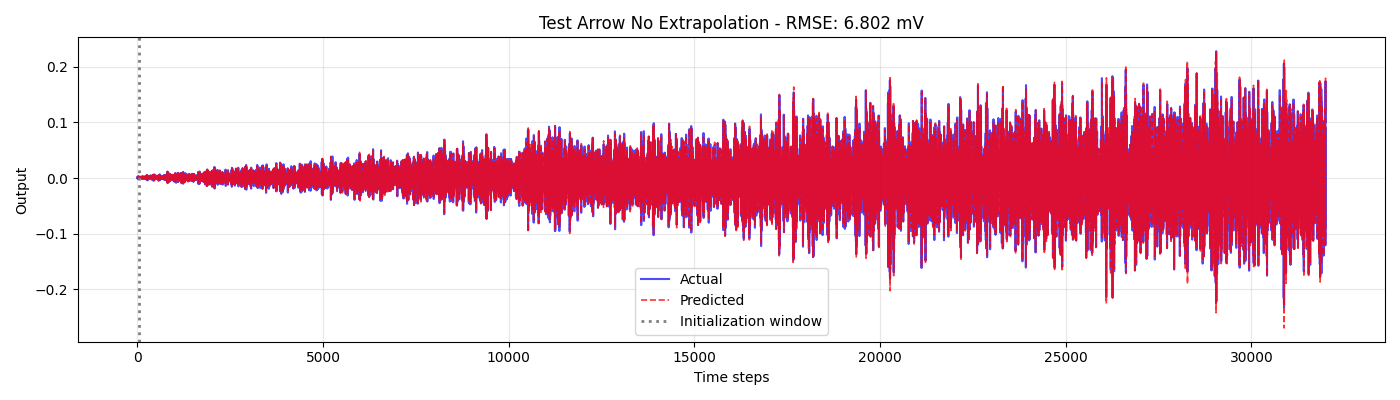

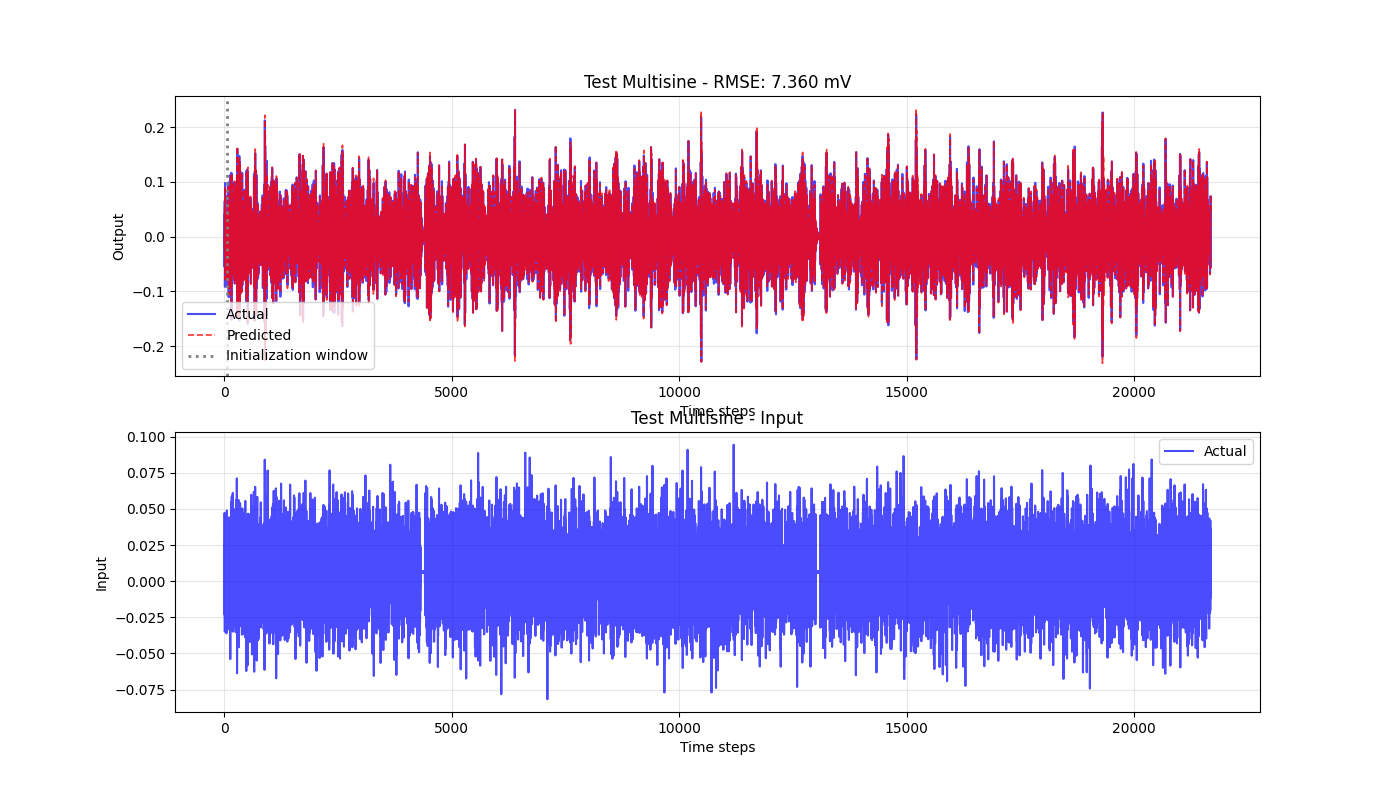

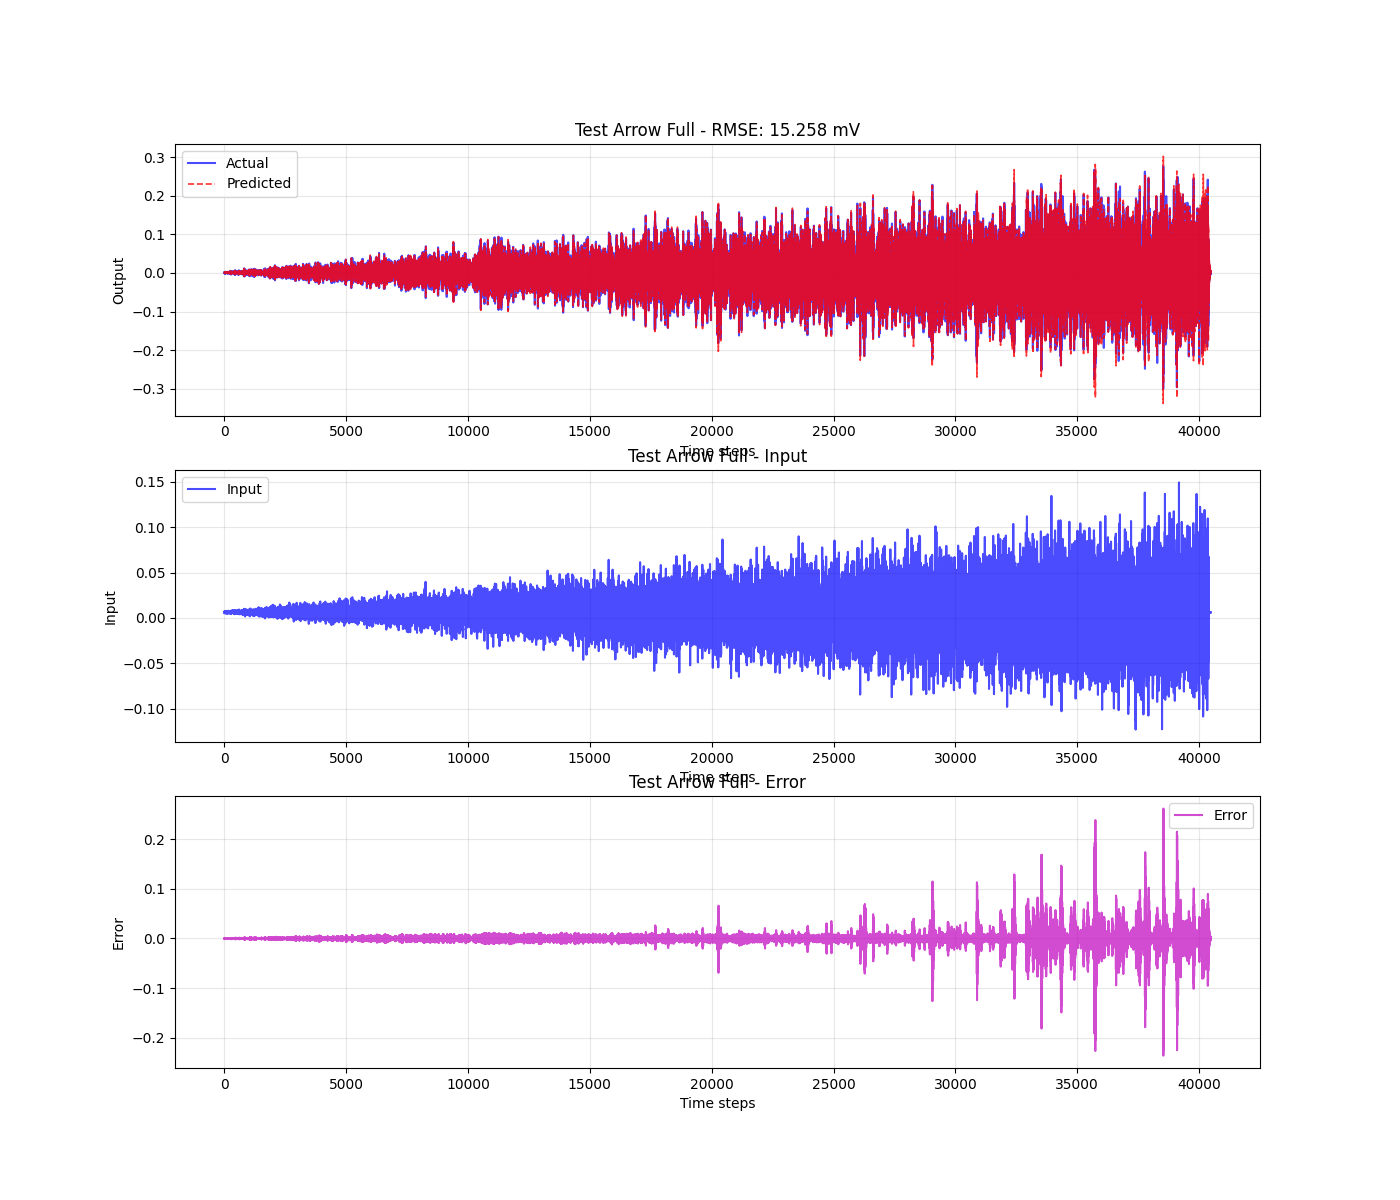

In [31]:
import matplotlib.pyplot as plt
import tikzplotlib
# Plot trajectories for all three test cases

# Test 1: Multisine
fig, axs = plt.subplots(2,1,figsize=(14, 8))
time_ms = np.arange(len(test_multisine.y))
axs[0].plot(time_ms, test_multisine.y, 'b-', label='Actual', linewidth=1.5, alpha=0.7)
axs[0].plot(time_ms, y_test_multisine_model, 'r--', label='Predicted', linewidth=1.2, alpha=0.8)
axs[0].axvline(n, color='gray', linestyle=':', linewidth=2, label='Initialization window')
axs[0].set_xlabel('Time steps')
axs[0].set_ylabel('Output')
axs[0].set_title(f'Test Multisine - RMSE: {test_multisine_RMSE:.3f} mV')
axs[0].legend(loc='best')
axs[0].grid(True, alpha=0.3)
axs[1].plot(time_ms, test_multisine.u, 'b-', label='Actual', linewidth=1.5, alpha=0.7)
axs[1].set_xlabel('Time steps')
axs[1].set_ylabel('Input')
axs[1].set_title('Test Multisine - Input')
axs[1].legend(loc='best')
axs[1].grid(True, alpha=0.3)

# Test 2: Arrow Full
# time_span = [1500, 2000]  # Adjust this range based on where the interesting dynamics occur
fig, axs = plt.subplots(3,1, figsize=(14, 12))
time_af = np.arange(len(test_arrow_full.y))
# ax.plot(time_af[time_span[0]:time_span[1]], test_arrow_full.y[time_span[0]:time_span[1]], 'b-', label='Actual', linewidth=1.5, alpha=0.7)
# ax.plot(time_af[time_span[0]:time_span[1]], y_test_arrow_full_model[time_span[0]:time_span[1]], 'r--', label='Predicted', linewidth=1.2, alpha=0.8)
axs[0].plot(time_af, test_arrow_full.y, 'b-', label='Actual', linewidth=1.5, alpha=0.7)
axs[0].plot(time_af, y_test_arrow_full_model, 'r--', label='Predicted', linewidth=1.2, alpha=0.8)
# ax.axvline(n, color='gray', linestyle=':', linewidth=2, label='Initialization window')
axs[0].set_xlabel('Time steps')
axs[0].set_ylabel('Output')
axs[0].set_title(f'Test Arrow Full - RMSE: {test_arrow_full_RMSE:.3f} mV')
axs[0].legend(loc='best')
axs[0].grid(True, alpha=0.3)
# tikzplotlib.save(project_root / "results" / "test_arrow_full.tex")
axs[1].sharex = axs[0]
axs[1].plot(time_af, test_arrow_full.u, 'b-', label='Input', linewidth=1.5, alpha=0.7)
axs[1].set_xlabel('Time steps')
axs[1].set_ylabel('Input')
axs[1].set_title('Test Arrow Full - Input')
axs[1].legend(loc='best')
axs[1].grid(True, alpha=0.3)
axs[2].plot(time_af, test_arrow_full.y - y_test_arrow_full_model, 'm-', label='Error', linewidth=1.5, alpha=0.7)
axs[2].set_xlabel('Time steps')
axs[2].set_ylabel('Error')
axs[2].set_title('Test Arrow Full - Error')
axs[2].legend(loc='best')
axs[2].grid(True, alpha=0.3)




# Test 3: Arrow No Extrapolation
fig, ax = plt.subplots(figsize=(14, 4))
time_ane = np.arange(len(test_arrow_no_extrapolation.y))
ax.plot(time_ane, test_arrow_no_extrapolation.y, 'b-', label='Actual', linewidth=1.5, alpha=0.7)
ax.plot(time_ane, y_test_arrow_no_extrapolation_model, 'r--', label='Predicted', linewidth=1.2, alpha=0.8)
ax.axvline(n, color='gray', linestyle=':', linewidth=2, label='Initialization window')
ax.set_xlabel('Time steps')
ax.set_ylabel('Output')
ax.set_title(f'Test Arrow No Extrapolation - RMSE: {test_arrow_no_extrapolation_RMSE:.3f} mV')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


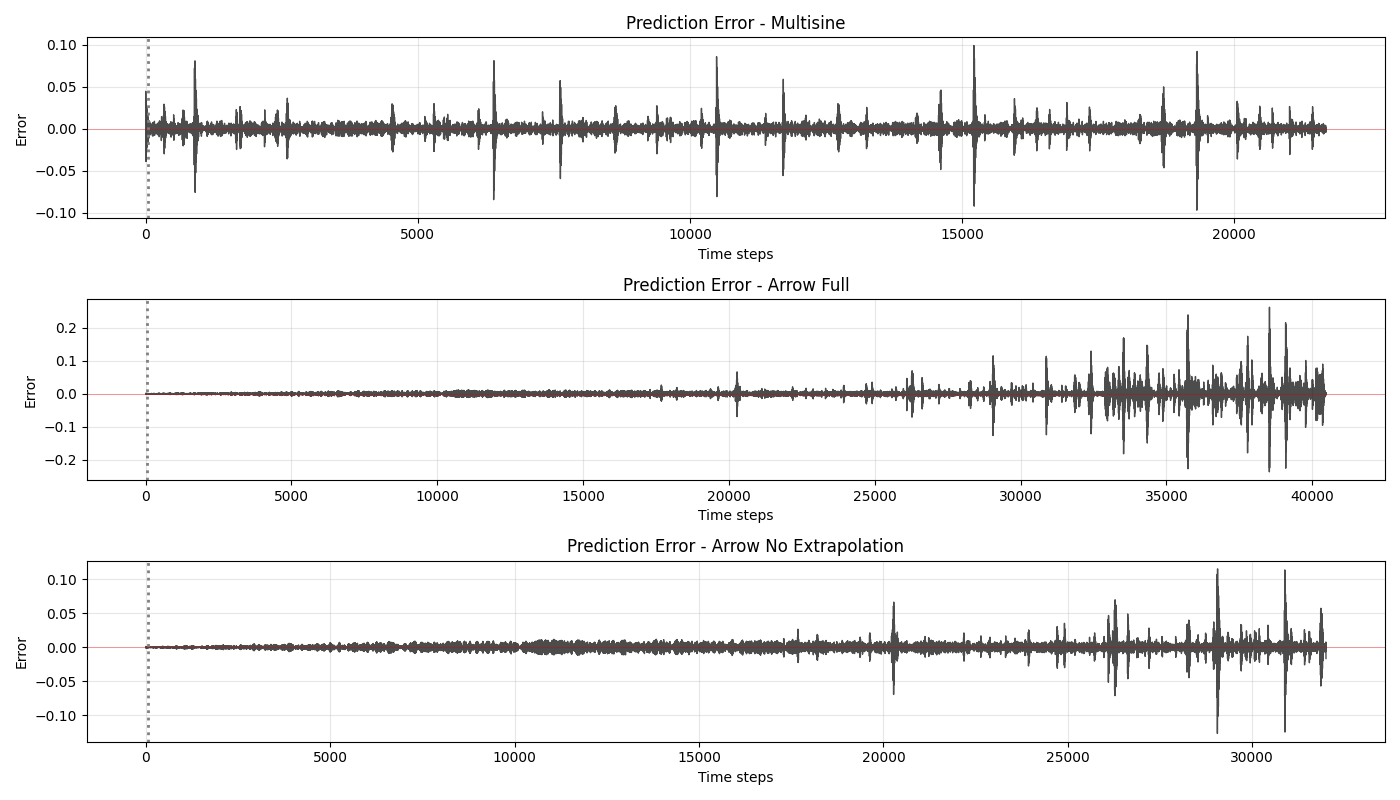

In [22]:

# Optional: Plot error trajectories
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Error for Multisine
ax = axes[0]
error_ms = test_multisine.y - y_test_multisine_model
ax.plot(time_ms, error_ms, 'k-', linewidth=1, alpha=0.7)
ax.axvline(n, color='gray', linestyle=':', linewidth=2, label='Initialization window')
ax.axhline(0, color='r', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Time steps')
ax.set_ylabel('Error')
ax.set_title(f'Prediction Error - Multisine')
ax.grid(True, alpha=0.3)

# Error for Arrow Full
ax = axes[1]
error_af = test_arrow_full.y - y_test_arrow_full_model
ax.plot(time_af, error_af, 'k-', linewidth=1, alpha=0.7)
ax.axvline(n, color='gray', linestyle=':', linewidth=2, label='Initialization window')
ax.axhline(0, color='r', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Time steps')
ax.set_ylabel('Error')
ax.set_title(f'Prediction Error - Arrow Full')
ax.grid(True, alpha=0.3)

# Error for Arrow No Extrapolation
ax = axes[2]
error_ane = test_arrow_no_extrapolation.y - y_test_arrow_no_extrapolation_model
ax.plot(time_ane, error_ane, 'k-', linewidth=1, alpha=0.7)
ax.axvline(n, color='gray', linestyle=':', linewidth=2, label='Initialization window')
ax.axhline(0, color='r', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Time steps')
ax.set_ylabel('Error')
ax.set_title(f'Prediction Error - Arrow No Extrapolation')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()